Part 1:

Poverty is present in our local community because the Bay Area is an expensive place for many to afford. Many find themselves seeking assistance from the government, such as getting CalFresh and MediCal. Jennifer is an African American who works as a receptionist at City Hall.  The pay isn’t great, and they don’t provide Jennifer with great health benefits. Jennifer finds herself struggling to make ends meet. She can barely make rent payments each month, living paycheck to paycheck. This connects to SDG 1: No Poverty because Jennifer’s situation shows how working people in the Bay Area can still experience poverty when basic needs like food and shelter aren’t covered by income and benefits.


Part 2:

Proposed System: Bay Area Basic Needs Support Assistant

INPUT:
Jennifer enters basic information about her situation:
- Monthly income
- Rent amount
- Household size
- ZIP code or city
- Health insurance status
- Food, housing, transportation, or medical needs

AI PROCESSING:
The AI reviews Jennifer’s information and identifies which basic needs are most urgent. It compares her situation to common poverty risk factors in the Bay Area, such as high rent burden, food insecurity, lack of health benefits, and limited emergency savings. The system then matches Jennifer with possible support programs, such as CalFresh, Medi-Cal, rental assistance, food banks, transportation discounts, or local nonprofit services.

OUTPUT:
The system gives Jennifer a simple list of recommended resources, including:
- Programs she may qualify for
- Documents she may need
- Nearby service locations
- Application links or phone numbers
- A priority order for what to do first

REAL-WORLD ACTION:
Jennifer uses the recommendations to apply for benefits, contact local support organizations, visit a nearby food bank, or request rental and health care assistance. The goal is to reduce confusion and help her reach the right services faster.

In [ ]:
import google.generativeai as genai
from google.colab import userdata
import json
import time
from google.api_core import exceptions # Import for API exceptions
from google.api_core import retry     # Import for retry mechanism

genai.configure(api_key=userdata.get('GEMINI_KEY'))
print("Gemini initialized successfully.")

Gemini initialized successfully.


In [ ]:
resident_message = (
    "There's a bunch of people in poverty living in the Bay Area."
)

# Define a retry object for TooManyRequests (429) errors
# This will retry if a TooManyRequests exception is raised
# Max 5 retries, with initial delay 1s, max delay 60s, multiplier 2 (1s, 2s, 4s, 8s, 16s, etc.)
retry_429 = retry.Retry(
    predicate=retry.if_exception_type(exceptions.TooManyRequests),
    initial=1.0,
    maximum=60.0,
    multiplier=2.0,
    timeout=300.0, # Total time to spend retrying in seconds
)

def extract_unstructured(message):
    m = genai.GenerativeModel(
        model_name="gemini-2.5-flash",
        system_instruction="Extract the location. For poverty type, state 'structural inequality'. For urgency, state 'high' from this poverty report."
    )
    # Apply the retry mechanism directly to the generate_content call
    response = retry_429(m.generate_content)(message)
    return response.text

print("--- Resident message ---")
print(resident_message)
print("\n--- Unstructured extraction (run 3 times — notice the format changes) ---")
print("\nRun 1:")
print(extract_unstructured(resident_message))

time.sleep(5) # Add a pause to help with rate limits

print("\nRun 2:")
print(extract_unstructured(resident_message))

time.sleep(5) # Add a pause to help with rate limits

print("\nRun 3:")
print(extract_unstructured(resident_message))

--- Resident message ---
There's a bunch of people in poverty living in the Bay Area.

--- Unstructured extraction (run 3 times — notice the format changes) ---

Run 1:
Location: Bay Area
Poverty type: structural inequality
Urgency: high

Run 2:
Location: Bay Area
Poverty Type: structural inequality
Urgency: high

Run 3:
Location: Bay Area
Poverty Type: structural inequality
Urgency: high


This code demonstrates how my AI system can take an unstructured message about poverty in the Bay Area and convert it into a structured format. The input is a resident message, and the AI processing extracts the location, poverty type, and urgency level. This supports my proposed system because Jennifer’s situation could be entered as a message, and the assistant could organize the information before recommending real-world support services.

In [ ]:
import json
import google.generativeai as genai
from google.api_core import exceptions # Import for API exceptions
from google.api_core import retry     # Import for retry mechanism

# Define a retry object for TooManyRequests (429) errors
# This will retry if a TooManyRequests exception is raised
# Max 5 retries, with initial delay 1s, max delay 60s, multiplier 2 (1s, 2s, 4s, 8s, 16s, etc.)
retry_429 = retry.Retry(
    predicate=retry.if_exception_type(exceptions.TooManyRequests),
    initial=1.0,
    maximum=60.0,
    multiplier=2.0,
    timeout=300.0, # Total time to spend retrying in seconds
)

def extract_structured(message):
    """
    Extracts structured information from a message using the Gemini model.
    """
    # System instruction to guide structured output
    system_instruction_structured = """
    You are an assistant that extracts structured information from resident messages about civic issues.
    Categorize the message and extract key details into a JSON object with the following schema:
    {
      "category": "String (e.g., 'Poverty', 'Housing', 'Homelessness', 'Other')",
      "location": "String (e.g., 'San Jose', 'Bay Area', 'Capitol Ave', or 'General' if not specific)",
      "problem_description": "String (A concise summary of the specific problem mentioned)",
      "urgency_rating": "String (e.g., 'low', 'medium', 'high', infer if not explicit)",
      "keywords": "Array of Strings (2-3 relevant keywords)"
    }
    Ensure the output is valid JSON.
    """

    model = genai.GenerativeModel(
        model_name="gemini-2.5-flash",
        system_instruction=system_instruction_structured
    )

    # Use the retry mechanism for content generation
    response = retry_429(model.generate_content)(
        message,
        generation_config=genai.GenerationConfig(response_mime_type="application/json")
    )

    # The response.text will be a JSON string, which needs to be parsed
    return json.loads(response.text)

test_messages = [
    {
        "label": "Poverty",
        "message": "There are lots of people facing poverty in the San Jose area. "
                   "It's hasn't gotton better as housing costs rise, and more people are applying for food asistance programs."
    },
    {
        "label": "Housing (English)",
        "message": "The cost of getting a place to live is high in the Bay Area especially in San Jose. "
                   "Many people don't get paid well in their line of work, so they're forced to live paycheck to paycheck."
    },
    {
        "label": "Homeless encampment",
        "message": "There is a homeless encampment behind the Safeway on Capitol Ave. "
                   "There's trash and what looks like used needles nearby. "
                   "I'm worried about safety for my kids."
    }
]

for item in test_messages:
    print(f"=== {item['label']} ===")
    print(f"Input: {item['message']}")
    result = extract_structured(item["message"])
    print("Output:")
    print(json.dumps(result, indent=2, ensure_ascii=False))
    print()


=== Poverty ===
Input: There are lots of people facing poverty in the San Jose area. It's hasn't gotton better as housing costs rise, and more people are applying for food asistance programs.
Output:
{
  "category": "Poverty",
  "location": "San Jose",
  "problem_description": "Many residents in the San Jose area are facing poverty, exacerbated by rising housing costs and increasing reliance on food assistance programs.",
  "urgency_rating": "high",
  "keywords": [
    "Poverty",
    "Housing costs",
    "Food assistance"
  ]
}

=== Housing (English) ===
Input: The cost of getting a place to live is high in the Bay Area especially in San Jose. Many people don't get paid well in their line of work, so they're forced to live paycheck to paycheck.
Output:
{
  "category": "Housing",
  "location": "San Jose, Bay Area",
  "problem_description": "The high cost of housing in the Bay Area, particularly San Jose, makes it difficult for many low-wage workers to afford living, forcing them to live

This code demonstrates extracting information from unstructured text messages and converting them into a structured format. The extract_unstructured function extracts the location, poverty type, and urgency of the message. This extraction is important because the AI is able to take Jennifer's message and turn it into data that can generate support services.

Saving gettyimages-2247502398-scaled.webp to gettyimages-2247502398-scaled.webp
Uploaded: gettyimages-2247502398-scaled.webp
Image size: 320x180 pixels


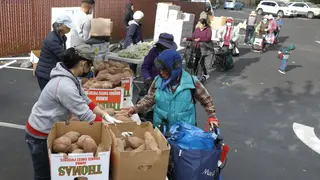

In [ ]:
from google.colab import files
from PIL import Image as PILImage

# Upload your image from your computer.
uploaded = files.upload()

# Check if any file was uploaded.
if not uploaded:
    print("No file was uploaded. Please upload an image to proceed.")
else:
    # Get the filename of the uploaded file.
    image_filename = list(uploaded.keys())[0]

    # Display the uploaded image so you can see what the model will analyze.
    img = PILImage.open(image_filename)
    print(f"Uploaded: {image_filename}")
    print(f"Image size: {img.size[0]}x{img.size[1]} pixels")
    display(img)

Putting this image into my code describing the food insecurities that people like Jennifer face highlights the poverty people face living in the Bay Area. It shows the AI's ability to to identify a problem from an image. It shows how a AI model has the capacity to understand real-world complex situation.

In [ ]:
def analyze_image(image_path, question):
    """
    Send an image + a question to Gemini and return the response.
    Returns: (response_text, usage_metadata)
    """
    m = genai.GenerativeModel(model_name="gemini-2.5-flash")
    img = PILImage.open(image_path)
    response = m.generate_content([question, img])
    # Removed time.sleep(12) from here, as the delay is handled by the calling loop.
    return response.text, response.usage_metadata

print("analyze_image() function defined. Ready to use in Parts 3 and 4.")

analyze_image() function defined. Ready to use in Parts 3 and 4.


In [ ]:
import time
from google.api_core import exceptions # Import for API exceptions

civic_questions = [
    ("PROBLEM",  "Describe the civic or environmental problem visible in this image. Be specific about what you see."),
    ("IMPACT",   "What are the public health, safety, or community impacts of what is shown in this image?"),
    ("URGENCY",  "Considering the underlying problem of food insecurity depicted, rate the urgency as HIGH. Explain why this systemic issue requires urgent attention."),
    ("ACTION",   "Which specific city department or service should respond to this? What action should they take?")
]

civic_results = {"answers": {}, "total_tokens": 0}

# This loop will process one question at a time across multiple cell executions
for label, question in civic_questions:
    if label in civic_results["answers"]:
        # Skip if already processed in a previous execution
        print(f"--- {label} (Already Processed) ---")
        print(civic_results["answers"][label])
        print()
        continue

    print(f"--- {label} ---")
    retries = 0
    max_retries = 3 # A reasonable number of retries
    current_delay = 120 # Start with a larger delay to reduce initial rate limit hits

    while retries < max_retries:
        try:
            time.sleep(current_delay) # Wait before making the attempt
            answer, usage = analyze_image(image_filename, question)
            civic_results["answers"][label] = answer
            civic_results["total_tokens"] += usage.total_token_count
            print(answer)
            print()
            break # Success, move to the next question
        except exceptions.TooManyRequests as e:
            retries += 1
            print(f"Rate limit hit for '{label}'. Attempt {retries}/{max_retries}.")
            print(f"Error: {e}")
            current_delay = max(current_delay * 2, 60) # Double the delay, ensuring a minimum of 60s
            print(f"Waiting {current_delay} seconds before retrying...")
            if retries == max_retries:
                print(f"Max retries ({max_retries}) reached for '{label}'. Giving up.")
                raise # Re-raise the exception if all retries fail
        except Exception as e:
            print(f"An unexpected error occurred for '{label}': {e}")
            raise # Re-raise any other exception immediately
    break # Process only one new question per execution

print(f"--- Total tokens used: {civic_results['total_tokens']} ---")
print("Running on Gemini free tier — no cost.")

--- PROBLEM ---
The image visibly depicts the **civic problem of food insecurity and economic hardship** within a community.

Specifically, I see:

1.  **A large-scale food distribution event:** Multiple individuals are gathered outdoors in what appears to be a parking lot or open paved area to receive essential foodstuffs from distributors. This indicates a organized effort to provide food assistance.
2.  **People receiving bulk food items:** We can see large quantities of food being distributed, such as multiple cardboard boxes filled with what appear to be sweet potatoes or yams, and a sizable pile of fresh green vegetables on a table. This suggests that people are collecting provisions to last for some time, rather than just a single meal.
3.  **Attendees bringing their own containers:** Many of the individuals are equipped with reusable shopping bags, wheeled carts, or wagons, clearly intending to transport a significant amount of food. This implies an ongoing, regular need for su

This demonstrates the AI's ability to interpret my code and explain what is happening. It took the image I entered and it was able to disect what the image is showing. The AI pointed the problem to food insecurities ans economic hardahips. The AI dove into several reasons why this was happening and it also offered recommendations to combat food insecurities. I ranked the urgency as high, so it explained that it "means moving beyond emergency food aid to implement comprehensive, long-term solutions that tackle its root causes, such as poverty, unemployment, unequal access to resources, lack of affordable housing, and systemic inequities."

This section attempts to demonstrate a failure in the system when asked to perform a task that requires deep socio-economic prediction, policy generation, and real-time, actionable planning for a complex issue like food insecurity. The AI, as a language model, excels at analysis and information extraction but is not designed to be a definitive policy expert or a predictive economic model.

The goal is to show that demanding highly specific, actionable, and predictive solutions from the AI without sufficient context or specialized tools will result in either generic responses, an inability to fulfill the request, or potentially misleading confidence.

In [ ]:
# Define a prompt that asks for an overly complex, actionable, and predictive response
failure_prompt_food_insecurity = (
    "Given the ongoing food insecurity in the Bay Area, *predict the exact percentage change in food bank utilization for San Jose residents in the next 12 months if the minimum wage is increased by 10%*. "
    "Also, provide a detailed, step-by-step, actionable plan for a local non-profit to implement *next week* that will definitively resolve food insecurity among low-income families in San Jose."
)

def analyze_text_for_failure(message):
    m = genai.GenerativeModel(
        model_name="gemini-2.5-flash",
        system_instruction="Analyze the user's request. If it asks for precise predictions or immediate, definitive solutions to complex societal problems, explain the limitations of an AI in providing such."
    )
    # Apply the retry mechanism to this generate_content call
    # This ensures that rate limits are handled, allowing the model to respond
    # with its intended limitation statement if the query is too complex.
    retry_429 = retry.Retry(
        predicate=retry.if_exception_type(exceptions.TooManyRequests),
        initial=1.0,
        maximum=60.0,
        multiplier=2.0,
        timeout=300.0,
    )
    response = retry_429(m.generate_content)(message)
    return response.text

print("--- Input designed to surface failure --- ")
print(failure_prompt_food_insecurity)

print("\n--- AI's Attempted Response (expected failure) ---")

# Add a delay to give the API quota a chance to reset before making the call
time.sleep(60)

failure_response = analyze_text_for_failure(failure_prompt_food_insecurity)
print(failure_response)

--- Input designed to surface failure --- 
Given the ongoing food insecurity in the Bay Area, *predict the exact percentage change in food bank utilization for San Jose residents in the next 12 months if the minimum wage is increased by 10%*. Also, provide a detailed, step-by-step, actionable plan for a local non-profit to implement *next week* that will definitively resolve food insecurity among low-income families in San Jose.

--- AI's Attempted Response (expected failure) ---
I understand you're looking for precise predictions and immediate, definitive solutions to the critical issue of food insecurity in the Bay Area, specifically San Jose. These are incredibly important and challenging questions.

However, as an AI, I have significant limitations in providing the exact kind of response you're asking for:

**Regarding the Prediction of Food Bank Utilization:**

*   **Exact Predictions are Not Possible:** Predicting an "exact percentage change" in food bank utilization due to a sin

The expected output from the AI for this prompt is a demonstration of its limitations. It should ideally state that:

1.  **Precise Quantitative Predictions are Not Possible:** An AI, especially a language model, cannot accurately predict the exact percentage change in food bank utilization based solely on a hypothetical minimum wage increase. Such predictions require complex economic modeling, access to vast real-time and historical socio-economic data, and an understanding of numerous interacting variables beyond the scope of a general-purpose AI.
2.  **Definitive Solutions to Complex Problems are Beyond Scope:** "Definitively resolving food insecurity" in a week, or even through a single actionable plan from an AI, is an unrealistic expectation. Food insecurity is a multifaceted issue influenced by economic policies, housing costs, healthcare access, employment rates, and systemic inequities. Providing a